## https://journals.ametsoc.org/view/journals/clim/19/8/jcli3691.1.xml?tab_body=pdf

Read the above paper. It says,
"Brubaker et al. (1993) extended the traditional Budyko model to a two-dimensional land region". It is expressed as E/E+Fin"

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_recycling_efficiency(all_results, model_name, experiment, season, 
                               vmin=0, vmax=1, cmap='RdYlBu'):
    """
    Plot recycling efficiency for a given model, experiment, and season.
    
    Parameters
    ----------
    all_results : dict
        Results dictionary from your analysis
    model_name : str
        Model name (e.g., 'UKESM1-0-LL')
    experiment : str
        Experiment name (e.g., 'SSP585', 'G6sulfur', 'HIST')
    season : str
        Season ('SUM', 'WIN', 'ANN')
    vmin, vmax : float
        Color scale limits
    cmap : str
        Colormap name
    """
    
    # Extract data
    data = all_results[model_name][experiment][season]['mean']
    
    # Create figure
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(180))
    
    # Plot
    # im = ax.pcolormesh(data.lon, data.lat, data, 
    #                    transform=ccrs.PlateCarree(),
    #                    cmap=cmap, vmin=vmin, vmax=vmax)
    im = ax.contourf(data.lon, data.lat, data,
                 levels=np.linspace(vmin, vmax, 20),
                 transform=ccrs.PlateCarree(), 
                 cmap='RdBu_r', extend='both')
    
    # Add features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', 
                       pad=0.05, shrink=0.8)
    cbar.set_label('Recycling Efficiency (ρ)', fontsize=12)
    
    # Title
    season_names = {'SUM': 'Summer', 'WIN': 'Winter', 'ANN': 'Annual'}
    plt.title(f'{model_name} - {experiment} - {season_names[season]} Recycling Efficiency', 
              fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax



In [2]:

EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

# EXP1 = "SSP585"     # subtrahend  (delta = EXP1 - EXP2)
# EXP2 = "HIST"

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# User-defined metadata
# =========================

varname = "pr"
varname_T = "tas"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    # "piControl": {"project": "CMIP",        "scenario": "piControl"},
    # "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:

# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data/GeoMIP")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
                    # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))


def calculate_recycling_efficiency(E, P, ua, va, hus):
    """
    Calculate moisture recycling efficiency ρ = E/(E+Fin) at each grid point.
    """
    # Extract data variables if Datasets
    if isinstance(E, xr.Dataset):
        E = E['evspsbl']
    if isinstance(P, xr.Dataset):
        P = P['pr']
    if isinstance(ua, xr.Dataset):
        ua = ua['ua']
    if isinstance(va, xr.Dataset):
        va = va['va']
    if isinstance(hus, xr.Dataset):
        hus = hus['hus']

    # Fill NaNs with zero before calculating moisture flux
    # (NaNs in upper atmosphere over land are typically zero flux)
    ua = ua.fillna(0)
    va = va.fillna(0)
    hus = hus.fillna(0)
    
    # Calculate moisture flux components: q*u and q*v
    qu = hus * ua  # (time, plev, lat, lon)
    qv = hus * va  # (time, plev, lat, lon)
    
    # Vertically integrate (trapezoid rule over pressure levels)
    g = 9.81  # m/s²
    qu_int = (qu.integrate('plev')) / g  # kg/(m·s)
    qv_int = (qv.integrate('plev')) / g  # kg/(m·s)
    
    # Calculate divergence of moisture flux
    dqu_dlon = qu_int.differentiate('lon')
    dqv_dlat = qv_int.differentiate('lat')
    
    # Convert to physical units (account for spherical geometry)
    R_earth = 6.371e6  # m
    lat_rad = np.deg2rad(qv_int.lat)
    dlon = np.deg2rad(2.5)  # grid spacing
    dlat = np.deg2rad(2.5)
    
    dqu_dx = dqu_dlon / (R_earth * np.cos(lat_rad) * dlon)
    dqv_dy = dqv_dlat / (R_earth * dlat)
    
    # Moisture flux convergence
    convergence = -(dqu_dx + dqv_dy)  # kg/(m²·s)
    
    # Fin = max(0, convergence) - only count INFLOW
    # Where convergence > 0, moisture flows IN
    # Where convergence < 0, moisture flows OUT
    Fin = convergence.where(convergence > 0, 0)
    
    # Recycling efficiency
    rho = E / (E + Fin)
    # rho=E/P
    # rho=convergence

    # # Bug checks:

    # print("plev values:", hus.plev.values)
    # print("plev increasing?", (hus.plev.diff('plev') > 0).all().values)
    # print("plev range:", hus.plev.min().values, hus.plev.max().values)

    # print("qu_int range:", qu_int.min().values, qu_int.max().values)
    # print("qv_int range:", qv_int.min().values, qv_int.max().values)
    
    # print("dqu_dlon range:", dqu_dlon.min().values, dqu_dlon.max().values)
    # print("dqv_dlat range:", dqv_dlat.min().values, dqv_dlat.max().values)
    
    # print("dqu_dx range:", dqu_dx.min().values, dqu_dx.max().values)
    # print("dqv_dy range:", dqv_dy.min().values, dqv_dy.max().values)

    # # Check for NaNs in your input data
    # print("NaNs in E:", np.isnan(E).sum().values)
    # print("NaNs in P:", np.isnan(P).sum().values)
    # print("NaNs in ua:", np.isnan(ua).sum().values)
    # print("NaNs in va:", np.isnan(va).sum().values)
    # print("NaNs in hus:", np.isnan(hus).sum().values)
    
    # # Check after multiplication
    # qu = hus * ua
    # qv = hus * va
    # print("NaNs in qu:", np.isnan(qu).sum().values)
    # print("NaNs in qv:", np.isnan(qv).sum().values)
    
    # Check after integration
    # print("NaNs in qu_int:", np.isnan(qu_int).sum().values)
    # print("NaNs in qv_int:", np.isnan(qv_int).sum().values)
    
    # print("convergence range:", convergence.min().values, convergence.max().values)
    
    # # Mask where E + Fin is too small (avoid division issues)
    # rho = rho.where((E + Fin) > 1e-10)
    
    # Option 1: Mask divergence areas (standard)
    # rho = (E / (E + Fin)).where(Fin > 0)
    
    # # Option 2: Use a different metric for divergence areas
    # rho = xr.where(Fin > 0, 
    #                E / (E + Fin),  # Recycling where convergence
    #                E / P)           # Evap ratio where divergence
    # # But label this clearly as a "hybrid metric"
    
    return rho
    
# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1
g  = 9.81      # m s-2


all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_pr = make_base("pr")
        base_ev = make_base("evspsbl")
        base_ua = make_base("ua")
        base_va = make_base("va")
        base_hus = make_base("hus")
        

        # ####### Handle base paths ######
        # ################################
        # ds_pr = load_model_data(base_pr, model_name, meta["scenario"], mf)
        # ds_ev = load_model_data(base_ev, model_name, meta["scenario"], mf)
        # ds_ua = load_model_data(base_ua, model_name, meta["scenario"], mf)
        # ds_va = load_model_data(base_va, model_name, meta["scenario"], mf)
        # ds_hus = load_model_data(base_hus, model_name, meta["scenario"], mf)

        load_model_data_alt_path
        ####### Handle ALTERNATE base paths ######
        ##########################################
        ds_pr = load_model_data_alt_path(base_pr, model_meta["institution"], model_name, meta["scenario"], model_meta["ensemble"], model_meta["grid"], mf,"pr")
        ds_ev = load_model_data_alt_path(base_ev, model_meta["institution"], model_name, meta["scenario"], model_meta["ensemble"], model_meta["grid"], mf,"evspsbl")
        ds_ua = load_model_data_alt_path(base_ua, model_meta["institution"], model_name, meta["scenario"], model_meta["ensemble"], model_meta["grid"], mf,"ua")
        ds_va = load_model_data_alt_path(base_va, model_meta["institution"], model_name, meta["scenario"], model_meta["ensemble"], model_meta["grid"], mf,"va")
        ds_hus = load_model_data_alt_path(base_hus, model_meta["institution"], model_name, meta["scenario"], model_meta["ensemble"], model_meta["grid"], mf,"hus")

        # # Read individual variables
        # da_pr  = mf.read_var(ds_pr, "pr")
        # da_ev  = mf.read_var(ds_ev, "evspsbl")
        # da_ua  = mf.read_var(ds_ua, "ua")
        # da_va  = mf.read_var(ds_va, "va")        
        # da_hus = mf.read_var(ds_hus,"hus")
        
        # Roll and regrid
        ds_pr  = roll_and_regrid(ds_pr)
        ds_ev  = roll_and_regrid(ds_ev)
        ds_ua  = roll_and_regrid(ds_ua)
        ds_va  = roll_and_regrid(ds_va)
        ds_hus = roll_and_regrid(ds_hus)
        
        print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months "
              f"({ds_pr.time.values[0]} → {ds_pr.time.values[-1]})")
        print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months "
              f"({ds_hus.time.values[0]} → {ds_hus.time.values[-1]})")


        # Compute MSEsfc = Cp*Tsfc + Lv*qsfc
        var[exp] = calculate_recycling_efficiency(ds_ev, ds_pr, ds_ua, ds_va, ds_hus)
        var[exp].name = "Recycling_Efficiency"

        print(f"  [{model_name}] {exp}: Recycling_Efficiency computed, shape={var[exp].shape}")

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR       ← unchanged
    # ----------------------------
    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR
    # ----------------------------
    for exp, da in var.items():
        t_start, t_end = _time_slice(exp)
        da_sliced = da.sel(time=slice(t_start, t_end))   # ← slice HERE
        n_months = da_sliced.sizes['time']
        print(f"  [{model_name}] {exp}: sliced to {n_months} months = "
              f"{n_months//12} years "
              f"({da_sliced.time.values[0]} → {da_sliced.time.values[-1]})")
        
        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
            "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
        }
    
    # ----------------------------
    # 3) 30-YR CLIMATOLOGY
    # ----------------------------
    results = {}
    
    for exp in var_by_year:
    
        results[exp] = {}
    
        for season in ["SUM", "WIN", "ANN"]:
    
            da_year = var_by_year[exp][season]
    
            results[exp][season] = {
                "mean": da_year.mean(dim="year") ,
                "sd":   da_year.std(dim="year")  ,
            }

    # ----------------------------
    # 4) Δbias (AFTER results built)
    # ----------------------------
    # Step 4
    if EXP1 in results and EXP2 in results:
        delta = {}
        delta_sd = {}
        for season in ["SUM", "WIN", "ANN"]:
            delta[season]    = results[EXP1][season]["mean"] - results[EXP2][season]["mean"]
            delta_sd[season] = np.sqrt(results[EXP1][season]["sd"]**2 + results[EXP2][season]["sd"]**2)
        results["delta_bias"]    = delta
        results["delta_bias_sd"] = delta_sd
        
        
    # Save results for models:
    all_results[model_name] = results

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/evspsbl/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/ua/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/va/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/hus/gn/latest
  [UKESM1-0-LL] G6sulfur: pr loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: hus loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: Recycling_Efficiency computed, shape=(972, 41, 144)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/evspsbl/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/ua/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp

In [5]:
# def print_var(varname):
#     return print(str(varname), varname)

# for var in [ds_pr, ds_ev, ds_ua, ds_va, ds_hus]:
#     print_var(var)

In [6]:
import dask

all_results_comp = dask.compute(all_results)[0]

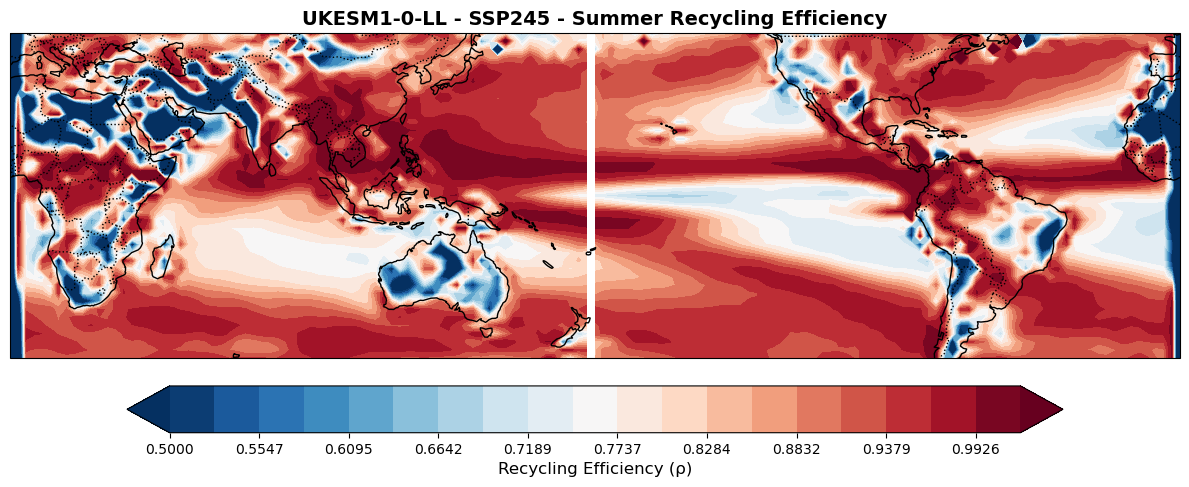

In [7]:
# Example usage:
fig, ax = plot_recycling_efficiency(all_results_comp, 'UKESM1-0-LL', 'SSP245', 'SUM', vmin=0.5, vmax=1.02)
plt.show()

In [8]:
def compute_regional_map(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"Rainfall_response_map_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if exp1 not in results or exp2 not in results:
            warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            mean1 = results[exp1][season]["mean"]
            mean2 = results[exp2][season]["mean"]
            delta_by_season[season] = mean1 - mean2

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with rel_mean for both '{exp1}' and '{exp2}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    #     fig, ax = plt.subplots(1, 1, figsize=(10, 5),
    #                        subplot_kw={'projection': ccrs.PlateCarree(0)})
    # ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

    # vmax   = 0.5
    # levels = np.linspace(-vmax, vmax, 21)
    # im = ax.contourf(lon, lat, mm_stitched, levels=levels, cmap='RdBu_r',
    #                  extend='both', transform=ccrs.PlateCarree())
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        # fig, ax = plt.subplots(figsize=(14, 5))
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        # then pcolormesh with transform=ccrs.PlateCarree(), shading="nearest"

        # im = ax.pcolormesh(LON, LAT, data,
        #                    cmap="RdBu_r", vmin=vmin, vmax=vmax,
        #                    shading="nearest")
        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        # cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
        #                     pad=0.08, fraction=0.04, aspect=40)
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)

        cbar.set_label(f"Δ Rainfall  ({exp1} − {exp2})  [mm day⁻¹]", fontsize=10)


        ###########################
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        #############################

        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        # ax.set_xlabel("Longitude", fontsize=9)
        # ax.set_ylabel("Latitude",  fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean Δ Rainfall  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)


        
        # Bombardi and Boos 2021 regions
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

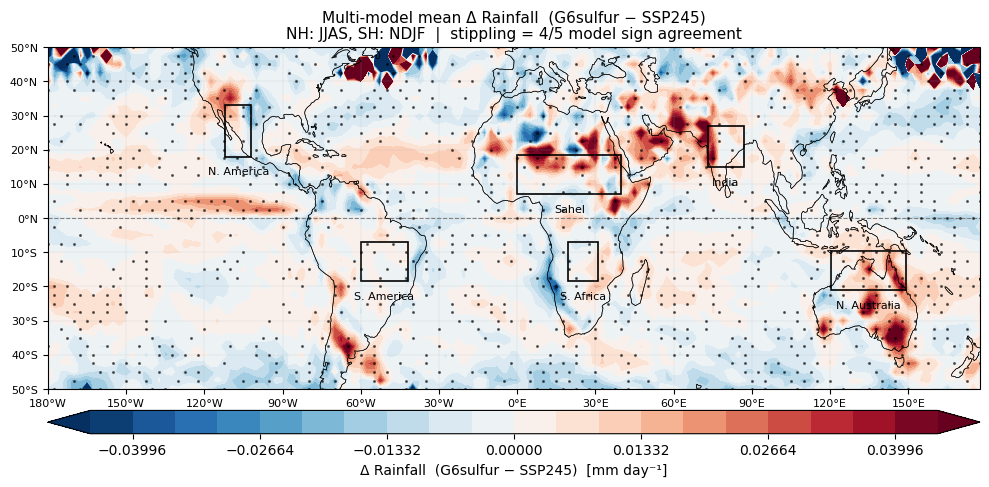

Returning → Rainfall_response_map_G6sulfur20212100_minus_SSP24520212100


In [9]:
delta_mean, stipple_mask = compute_regional_map(
    all_results_comp,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=False
)

In [12]:



# ================================================================
# Main function
# ================================================================

def compute_regional_bar(
    all_results,
    exp1,
    exp2,
    trop_bound=30,
    land_mask=None,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    """
    Compute (and optionally plot) the regional bar data for (exp1 - exp2).

    Parameters
    ----------
    all_results : dict
        Top-level results dict keyed by model name.
        Each model must contain results[exp1] and results[exp2],
        each with seasons 'SUM' and 'WIN' containing 'mean' DataArrays.
    exp1, exp2 : str
        Experiment names, e.g. 'G6sulfur', 'SSP585', 'SSP245', 'HIST'.
        Time slicing is determined automatically from the experiment name.
    trop_bound : int
        Tropical latitude boundary (degrees). Default 30.
    land_mask : xarray.DataArray or None
        Boolean land mask. If None, built from regionmask.
    plot : bool
        Whether to display the bar chart. Default True.
    save_fig : bool
        Whether to save the figure. Default False.
    fig_path : str or None
        Path for saved figure. Auto-generated if None and save_fig=True.

    Returns
    -------
    bar_data : dict
        Keys: 'labels', 'means', 'colors', 'per_model_all'.
        Stored in the caller's namespace as
        bar_data_{exp1}{y1}_minus_{exp2}{y2}.
    var_name : str
        The variable name string (so you know what to look up in the dict).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import xarray as xr
    import warnings

    label1 = _exp_year_label(exp1)
    label2 = _exp_year_label(exp2)
    var_name = f"MoistureRecycling_bar_data_{exp1}{label1}_minus_{exp2}{label2}"
    t1 = _time_slice(exp1)
    t2 = _time_slice(exp2)

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if exp1 not in results or exp2 not in results:
            warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            mean1 = results[exp1][season]["mean"]
            mean2 = results[exp2][season]["mean"]

            # Time-subset if the DataArray still has a time/year dimension
            for dim in ("time", "year"):
                if dim in mean1.dims:
                    mean1 = mean1.sel({dim: slice(*t1)})
                if dim in mean2.dims:
                    mean2 = mean2.sel({dim: slice(*t2)})

            delta_by_season[season] = mean1 - mean2

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with both '{exp1}' and '{exp2}' found.")

    stacked = xr.concat(delta_list, dim="model")        # (model, lat, lon)
    lat     = stacked.lat.values
    lon     = stacked.lon.values

    # ------------------------------------------------------------------ #
    # 2.  Land / ocean mask
    # ------------------------------------------------------------------ #
    if land_mask is None:
        try:
            import regionmask
            land_110     = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            mask_np      = land_110.mask(lon, lat)
            land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
        except ImportError:
            warnings.warn("regionmask not found — using all-ocean proxy.")
            land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
    else:
        land_mask_da = land_mask.interp(lat=lat, lon=lon, method="nearest") > 0.5

    ocean_mask_da = ~land_mask_da

    # ------------------------------------------------------------------ #
    # 3.  Monsoon region boxes
    # ------------------------------------------------------------------ #
    regions = {
        "N. America":   {"lon": (248, 258),   "lat": (18,    33)},
        "S. America":   {"lon": (300, 318),   "lat": (-18.5, -7)},
        "Sahel":        {"lon": (0,   40),    "lat": (7,   18.5)},
        "S. Africa":    {"lon": (19.5, 31),   "lat": (-18.5, -7)},
        "India":        {"lon": (73,  87),    "lat": (15,    27)},
        "N. Australia": {"lon": (120.5, 149), "lat": (-21,  -9.5)},
    }

    # ------------------------------------------------------------------ #
    # 4.  Area-weighted means
    # ------------------------------------------------------------------ #
    weights    = np.cos(np.deg2rad(lat))
    weights_da = xr.DataArray(weights, dims=["lat"], coords={"lat": lat})

    def area_mean(data_3d, mask_2d):
        masked = data_3d.where(mask_2d)
        w      = weights_da.where(mask_2d)
        return (masked * w).sum(["lat", "lon"]) / w.sum(["lat", "lon"])

    def to_180(l):
        return ((l + 180) % 360) - 180

    def box_mask(lon_range, lat_range):
        lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
        lat0, lat1 = lat_range
        lon_da, lat_da = stacked.lon, stacked.lat
        if lon0 <= lon1:
            lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
        else:
            lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
        return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

    labels        = []
    means         = []
    colors        = []
    per_model_all = []

    land_ocean = [("Land",  land_mask_da,  "#E07B3A"),
                  ("Ocean", ocean_mask_da, "#3A7BE0")]
    region_colors = ["#D45F8B", "#8B5FD4", "#5FD4A0",
                     "#D4A05F", "#5FAFD4", "#A0D45F"]

    for label, mask, color in land_ocean:
        pm = area_mean(stacked, mask).values
        labels.append(label)
        means.append(float(np.nanmean(pm)))
        colors.append(color)
        per_model_all.append(pm)

    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask = box_mask(coords["lon"], coords["lat"])
        pm    = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(pm)))
        colors.append(rcol)
        per_model_all.append(pm)

    means = np.array(means)
    x     = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 5.  Plot (optional)
    # ------------------------------------------------------------------ #
    fig = None
    if plot:
        fig, ax = plt.subplots(figsize=(11, 5))

        ax.bar(x, means, color=colors, edgecolor="k",
               linewidth=0.7, alpha=0.85, zorder=3)

        rng      = np.random.default_rng(42)
        n_models = len(delta_list)
        for i, pm in enumerate(per_model_all):
            jitter = rng.uniform(-0.18, 0.18, size=len(pm))
            ax.scatter(x[i] + jitter, pm, color="k", s=20,
                       zorder=5, alpha=0.6, linewidths=0.4, edgecolors="white")

        ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(
            f"$\\Delta$RESPONSE$_{{{exp1} - {exp2}}}$ (mm day$^{{-1}}$)",
            fontsize=10)
        ax.set_title(
            f"Multi-model mean $\\Delta$ precip response\n"
            f"({exp1} − {exp2})  |  NH: JJAS, SH: NDJF  |  "
            f"dots = individual models ({n_models} models)",
            fontsize=11)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)

        legend_patches = [
            mpatches.Patch(color="#E07B3A", label="Land"),
            mpatches.Patch(color="#3A7BE0", label="Ocean"),
            mpatches.Patch(color="grey",    label="Monsoon regions"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="k",
                       markersize=6, alpha=0.6, label="Individual models"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
        # ax.set_ylim(-0.6, 1.30)
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    # ------------------------------------------------------------------ #
    # 6.  Package and return
    # ------------------------------------------------------------------ #
    bar_data = {
        "labels":        labels,
        "means":         means,
        "colors":        colors,
        "per_model_all": per_model_all,
    }

    print(f"Returning → {var_name}")
    return bar_data, var_name





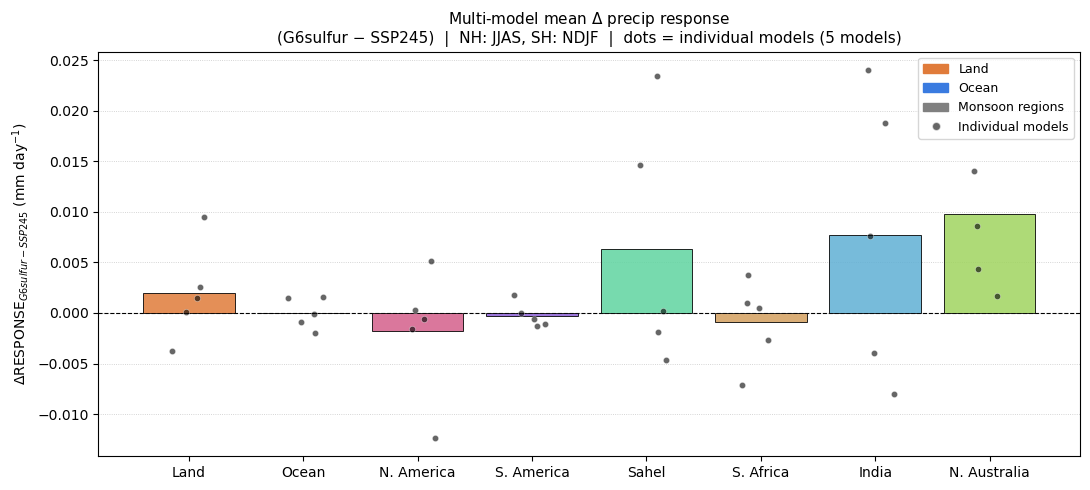

Returning → MoistureRecycling_bar_data_G6sulfur20212100_minus_SSP24520212100


In [13]:
# G6sulfur (2071-2100) minus SSP585 (2071-2100)
# bar_data, name = compute_regional_bar(all_results, "G6sulfur", "SSP585")
bar_data, name = compute_regional_bar(all_results_comp, EXP1, EXP2)
globals()[name] = bar_data     # stores as bar_data_G6sulfur20712100_minus_SSP58520712100

In [14]:
# In[5]:
import pickle
from pathlib import Path

SAVE_DIR = Path('/home/users/bidyut/UoE/20260218_Monsoons')
pkl_path = SAVE_DIR / 'MoistureRecycling_bar_data_G6sulfur20212100_minus_SSP24520212100.pkl'

# Load existing or start fresh
if pkl_path.exists():
    with open(pkl_path, 'rb') as f:
        all_bar_data_Relative = pickle.load(f)
else:
    all_bar_data_Relative = {}

# Compute
all_bar_data_Relative[name] = bar_data

# Save
with open(pkl_path, 'wb') as f:
    pickle.dump(all_bar_data_Relative, f)
print(f"All keys now: {list(all_bar_data_Relative.keys())}")

All keys now: ['MoistureRecycling_bar_data_G6sulfur20212100_minus_SSP24520212100']
